In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.metrics import classification_report,accuracy_score,ConfusionMatrixDisplay
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight,compute_class_weight
import osmnx as ox
from scipy.spatial import cKDTree

In [2]:
RANDOM_STATE = 67

In [21]:
df = pd.read_csv('../data/processed/cleaned_crime_data.csv',low_memory=False)
# df = df.sample(n=10000,random_state=RANDOM_STATE)
df.head()

,crime_type,description,location_desc,arrested,latitude,longitude,date,time,city,race,sex,age_group,crime_category,hour,year,month,day_of_week
0,DECEPTIVE PRACTICE,CREDIT CARD FRAUD,OTHER (SPECIFY),False,41.891990,-87.611462,2025-12-31,23:45:00,Chicago,NaN,NaN,NaN,FRAUD,23.0,2025,12,2
1,THEFT,OVER $500,OTHER (SPECIFY),False,41.891990,-87.611462,2025-12-31,23:45:00,Chicago,NaN,NaN,NaN,PROPERTY,23.0,2025,12,2
2,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,41.898388,-87.655790,2025-12-31,23:44:00,Chicago,NaN,NaN,NaN,VIOLENT,23.0,2025,12,2
3,WEAPONS VIOLATION,UNLAWFUL POSSESSION - HANDGUN,STREET,True,41.764554,-87.692250,2025-12-31,23:40:00,Chicago,NaN,NaN,NaN,WEAPONS,23.0,2025,12,2
4,ROBBERY,STRONG ARM - NO WEAPON,RESIDENCE - PORCH / HALLWAY,False,41.770945,-87.588017,2025-12-31,23:40:00,Chicago,NaN,NaN,NaN,VIOLENT,23.0,2025,12,2


In [22]:
# Defining POIs
tags = {
    'amenity': ['bar', 'pub', 'nightclub', 'atm', 'bank', 'school', 'hospital'],
    'public_transport': ['station', 'stop_position'],
    'shop': ['convenience', 'supermarket']
}

chicago_pois = ox.features_from_place('Chicago, Illinois', tags=tags)
nyc_pois = ox.features_from_place('New York City, New York', tags=tags)
la_pois = ox.features_from_place('Los Angeles, California', tags=tags)

In [23]:
def get_nearest_distance(crime_df, poi_df):
    poi_coords = poi_df.copy()
    poi_coords = poi_coords.to_crs('EPSG:3857')
    poi_coords['lat'] = poi_coords.geometry.centroid.to_crs('EPSG:4326').y
    poi_coords['lon'] = poi_coords.geometry.centroid.to_crs('EPSG:4326').x
    poi_coords = poi_coords.dropna(subset=['lat', 'lon'])
    
    tree = cKDTree(poi_coords[['lat', 'lon']].values)
    distances, _ = tree.query(crime_df[['latitude', 'longitude']].values, k=1)
    return distances

def count_within_radius(crime_df, poi_df, radius=0.005):
    poi_coords = poi_df.copy()
    poi_coords = poi_coords.to_crs('EPSG:3857')
    poi_coords['lat'] = poi_coords.geometry.centroid.to_crs('EPSG:4326').y
    poi_coords['lon'] = poi_coords.geometry.centroid.to_crs('EPSG:4326').x
    poi_coords = poi_coords.dropna(subset=['lat', 'lon'])
    
    tree = cKDTree(poi_coords[['lat', 'lon']].values)
    counts = tree.query_ball_point(crime_df[['latitude', 'longitude']].values, r=radius)
    return [len(c) for c in counts]

In [24]:
# Process each city
for city, pois in [('Chicago', chicago_pois), ('New York', nyc_pois), ('Los Angeles', la_pois)]:
    mask = df['city'] == city
    
    for amenity in ['bar', 'atm', 'school', 'hospital']:
        subset = pois[pois['amenity'] == amenity]
        
        if len(subset) == 0:
            df.loc[mask, f'dist_to_{amenity}'] = np.nan
            df.loc[mask, f'{amenity}s_within_500m'] = 0
            continue
        
        df.loc[mask, f'dist_to_{amenity}'] = get_nearest_distance(df[mask], subset)
        df.loc[mask, f'{amenity}s_within_500m'] = count_within_radius(df[mask], subset)

In [25]:
df.columns

Index(['crime_type', 'description', 'location_desc', 'arrested', 'latitude',
       'longitude', 'date', 'time', 'city', 'race', 'sex', 'age_group',
       'crime_category', 'hour', 'year', 'month', 'day_of_week', 'dist_to_bar',
       'bars_within_500m', 'dist_to_atm', 'atms_within_500m', 'dist_to_school',
       'schools_within_500m', 'dist_to_hospital', 'hospitals_within_500m'],
      dtype='object')

In [26]:
features = [
    'latitude', 'longitude',
    'hour','day_of_week','month','city','arrested',
    'dist_to_bar','dist_to_atm','dist_to_school','dist_to_hospital',
    'bars_within_500m','atms_within_500m','schools_within_500m'
]

X = df[features].copy()
y = df['crime_category']

In [27]:
X.isna().sum()

latitude                     0
longitude                    0
hour                   1416414
day_of_week                  0
month                        0
city                         0
arrested                     0
dist_to_bar                  0
dist_to_atm                  0
dist_to_school               0
dist_to_hospital             0
bars_within_500m             0
atms_within_500m             0
schools_within_500m          0
dtype: int64

In [28]:
# Fill nulls so model doesn't do weird things
X['hour'] = X['hour'].fillna(-1)

In [29]:
print(df['year'].value_counts().sort_index())

year
2018    603551
2019    558690
2022    481310
2023    546588
2024    577908
2025    526396
Name: count, dtype: int64


In [30]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)

In [31]:
preprocessor = ColumnTransformer(transformers=[
    ('cat',OneHotEncoder(handle_unknown='ignore'),['city'])
],remainder='passthrough')

pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(n_estimators=50,random_state=RANDOM_STATE,n_jobs=-1,class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

# le = LabelEncoder()
# y_train_enc = le.fit_transform(y_train)
# y_test_enc = le.transform(y_test)

# classes = np.unique(y_train_enc)
# weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_enc)
# weight_dict = dict(zip(classes, weights * 0.5))

# sample_weights = np.array([weight_dict[y] for y in y_train_enc])

# xgb_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', XGBClassifier(
#         n_estimators=100,
#         random_state=42,
#         n_jobs=-1,
#         tree_method='hist'
#     ))
# ])

# xgb_pipeline.fit(X_train, y_train_enc, model__sample_weight=sample_weights)
# y_pred_enc = xgb_pipeline.predict(X_test)
# y_pred = le.inverse_transform(y_pred_enc)
# print(classification_report(y_test, y_pred))

# XGBOOST(balanced) OUTPUT
#               precision    recall  f1-score   support

#         DRUG       0.23      0.51      0.32     41994
#        FRAUD       0.13      0.49      0.21     30938
#        OTHER       0.21      0.19      0.20     58820
#     PROPERTY       0.60      0.36      0.45    234375
# PUBLIC ORDER       0.25      0.53      0.34     63765
#      VIOLENT       0.48      0.15      0.23    205305
#      WEAPONS       0.13      0.33      0.18     23692

#     accuracy                           0.31    658889
#    macro avg       0.29      0.36      0.27    658889
# weighted avg       0.43      0.31      0.32    658889

              precision    recall  f1-score   support

        DRUG       0.43      0.45      0.44     41994
       FRAUD       0.22      0.14      0.17     30938
       OTHER       0.27      0.24      0.25     58820
    PROPERTY       0.58      0.63      0.60    234375
PUBLIC ORDER       0.41      0.44      0.43     63765
     VIOLENT       0.48      0.47      0.48    205305
     WEAPONS       0.20      0.18      0.19     23692

    accuracy                           0.48    658889
   macro avg       0.37      0.36      0.37    658889
weighted avg       0.47      0.48      0.47    658889



In [32]:
joblib.dump(pipeline, '../models/crime_model_poi.pkl',compress=3)

['../models/crime_model_poi.pkl']

In [33]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        DRUG       0.43      0.45      0.44     41994
       FRAUD       0.22      0.14      0.17     30938
       OTHER       0.27      0.24      0.25     58820
    PROPERTY       0.58      0.63      0.60    234375
PUBLIC ORDER       0.41      0.44      0.43     63765
     VIOLENT       0.48      0.47      0.48    205305
     WEAPONS       0.20      0.18      0.19     23692

    accuracy                           0.48    658889
   macro avg       0.37      0.36      0.37    658889
weighted avg       0.47      0.48      0.47    658889



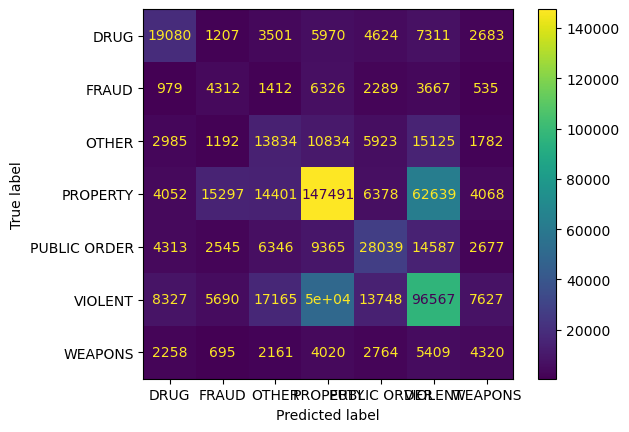

In [34]:
ConfusionMatrixDisplay.from_predictions(y_pred,y_test)